In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, CompoundKernel, WhiteKernel, RBF
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

## Using RBF/Matern kernel (GP - 6D and plot 1D)

In [85]:
data_path = r'D:\KIT\cafm_lhs_300.npz'
data = np.load(data_path)
X, Y = data['X'][:50], data['Y'][:50]
print(X)
mean_cross_time_idx = 0
density_idx = 4

# X_density = X[:,density_idx]
y_mean_cross_time = Y[:, mean_cross_time_idx]

x_train_raw, x_test_raw, y_train, y_test = train_test_split(X, y_mean_cross_time, test_size= 0.2, random_state=42)

scale_x = StandardScaler()
scale_y = StandardScaler()

x_train = scale_x.fit_transform(x_train_raw)
x_test = scale_x.transform(x_test_raw)
y_train = scale_y.fit_transform(y_train.reshape(-1,1)).ravel()

# kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-1, 15.0), nu=2.5)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=7)
gaussian_process.fit(x_train, y_train)
gaussian_process.kernel_



[[1.45660278e+00 6.34268536e-01 1.18141402e+01 1.08614035e+00
  8.01717468e-01 4.00040629e-01]
 [1.48330363e+00 6.12023226e-01 3.07871886e+01 8.17465637e-01
  4.82887606e-01 3.63455392e-01]
 [9.76949693e-01 5.36962064e-01 3.20556586e+01 1.35672736e+00
  2.39336246e-01 3.65603046e-02]
 [1.57912632e+00 5.27280559e-01 2.23241912e+01 1.00172126e+00
  4.36087906e-01 3.10178131e-01]
 [1.11792431e+00 7.33008935e-01 3.71533279e+01 1.53054986e+00
  7.74537132e-01 2.02194918e-01]
 [1.10734730e+00 6.06720817e-01 1.92674175e+01 1.27101211e+00
  8.78591333e-01 1.64684214e-01]
 [9.56986876e-01 4.95873825e-01 2.27773091e+01 8.70213829e-01
  3.20688544e-01 3.38612203e-01]
 [1.10479929e+00 7.82812722e-01 1.95167740e+01 1.29918730e+00
  8.15837565e-01 1.84519453e-01]
 [1.59284668e+00 4.18100413e-01 1.54800092e+01 8.37313701e-01
  2.68639227e-01 4.28891915e-01]
 [1.41145289e+00 5.92032118e-01 2.84541084e+01 1.16648336e+00
  8.85580609e-01 1.81424499e-02]
 [1.02221759e+00 6.02548173e-01 1.32434764e+01 1.5

1.14**2 * Matern(length_scale=2.15, nu=2.5)

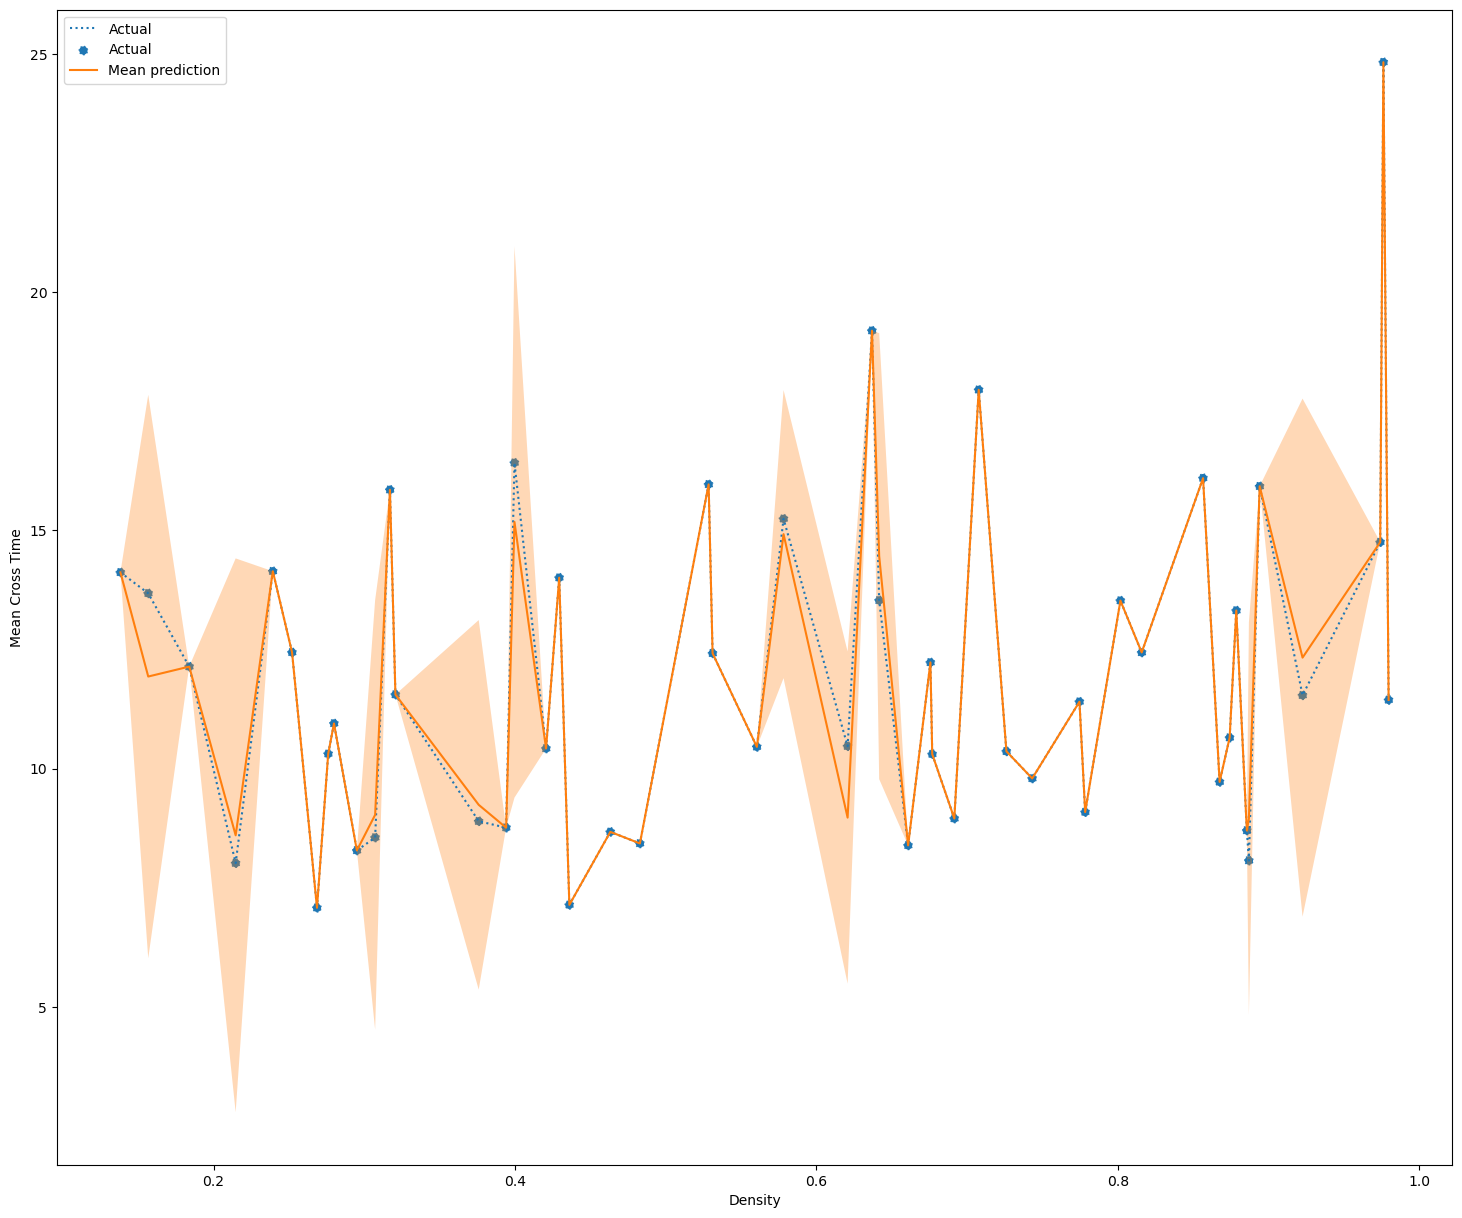

In [86]:
X_scaled = scale_x.transform(X)
mean_prediction, std_prediction = gaussian_process.predict(X_scaled, return_std=True)

idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(18,15))
plt.plot(X[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.scatter(X[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.plot(X[idx, density_idx], scale_y.inverse_transform(mean_prediction.reshape(-1,1)).ravel()[idx], label="Mean prediction")

plt.fill_between(
    X[idx, density_idx],
    scale_y.inverse_transform(
        (mean_prediction - 1.96*std_prediction).reshape(-1,1)
    ).ravel()[idx],
    scale_y.inverse_transform(
        (mean_prediction + 1.96*std_prediction).reshape(-1,1)
    ).ravel()[idx],
    alpha=0.3
)

plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()

## Test points and there varience 

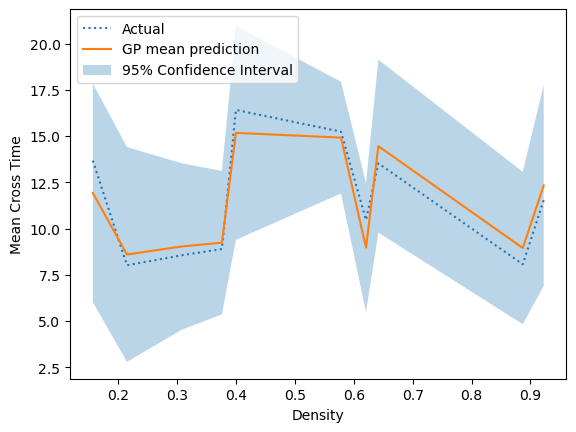

In [87]:
X_scaled = scale_x.transform(X)
mean_prediction, std_prediction = gaussian_process.predict(x_test, return_std=True)

y_pred = scale_y.inverse_transform(mean_prediction.reshape(-1,1)).ravel()

lower_scale = scale_y.inverse_transform((mean_prediction-1.96*std_prediction).reshape(-1,1)).ravel()
upper_scale = scale_y.inverse_transform((mean_prediction+1.96*std_prediction).reshape(-1,1)).ravel()
idx = np.argsort(x_test[:, density_idx])


plt.plot(x_test_raw[idx,density_idx], y_test[idx], linestyle = 'dotted', label = 'Actual')
plt.plot(x_test_raw[idx, density_idx], y_pred[idx], label = 'GP mean prediction')
plt.fill_between(x_test_raw[idx, density_idx], lower_scale[idx], upper_scale[idx], alpha = 0.3, label = '95% Confidence Interval')
plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()

### ploting together 

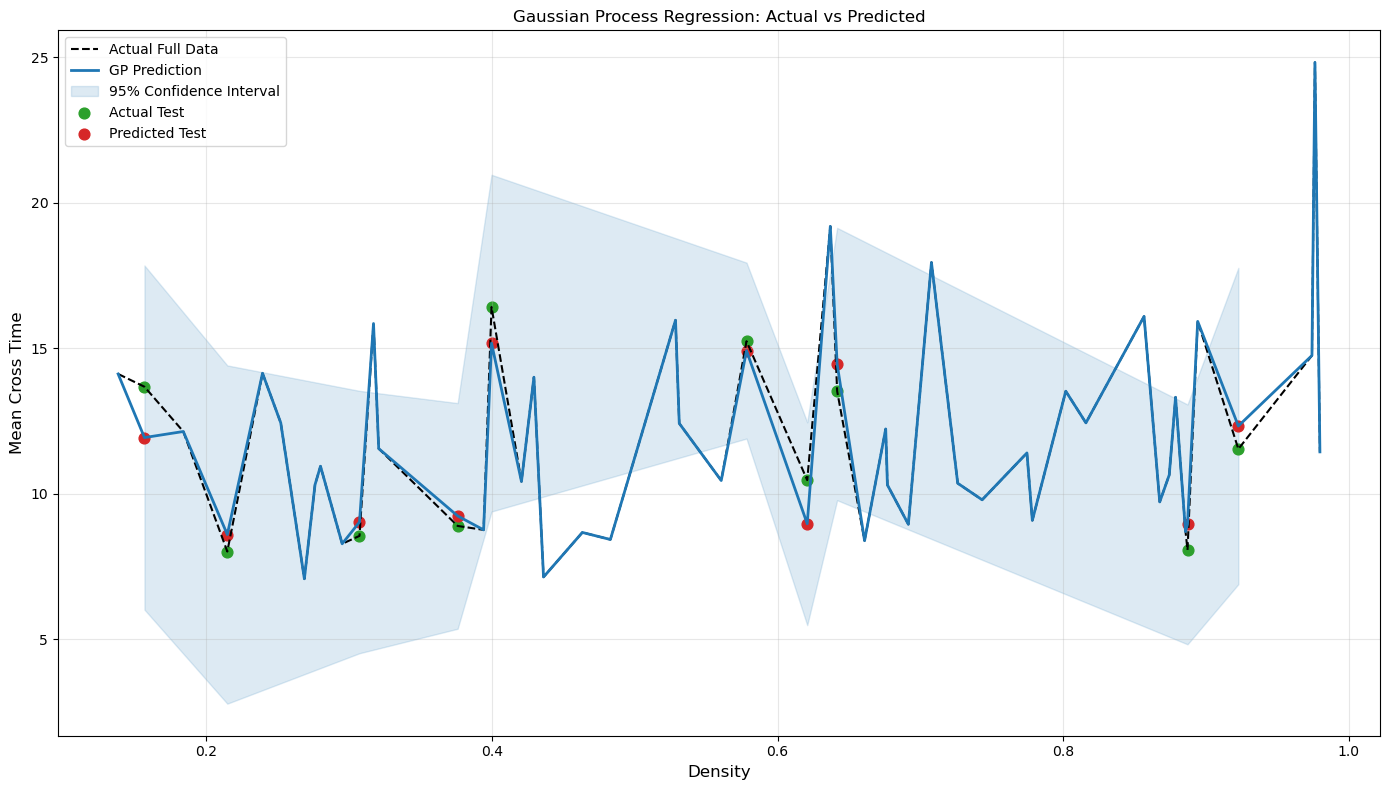

In [88]:
X_scaled = scale_x.transform(X)

idx_train = np.argsort(X[:, density_idx])
idx_test = np.argsort(x_test[:, density_idx])

mean_prediction, std_prediction = gaussian_process.predict(X_scaled, return_std=True)
mean_prediction1, std_prediction1 = gaussian_process.predict(x_test, return_std=True)
lower_scale = scale_y.inverse_transform((mean_prediction1-1.96*std_prediction1).reshape(-1,1)).ravel()
upper_scale = scale_y.inverse_transform((mean_prediction1+1.96*std_prediction1).reshape(-1,1)).ravel()
# idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(14,8))

# Actual full data
plt.plot(
    X[idx_train, density_idx],
    y_mean_cross_time[idx_train],
    '--',
    color='black',
    linewidth=1.5,
    label='Actual Full Data'
)

# GP prediction
plt.plot(
    X[idx_train, density_idx],
    scale_y.inverse_transform(
        mean_prediction.reshape(-1,1)
    ).ravel()[idx_train],
    color='tab:blue',
    linewidth=2,
    label='GP Prediction'
)

# Confidence interval
plt.fill_between(
    x_test_raw[idx_test, density_idx],
    lower_scale[idx_test],
    upper_scale[idx_test],
    color='tab:blue',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Actual test
plt.scatter(
    x_test_raw[idx_test, density_idx],
    y_test[idx_test],
    color='tab:green',
    s=60,
    label='Actual Test'
)

# Predicted test
plt.scatter(
    x_test_raw[idx_test, density_idx],
    y_pred[idx_test],
    color='tab:red',
    s=60,
    label='Predicted Test'
)

plt.xlabel("Density", fontsize=12)
plt.ylabel("Mean Cross Time", fontsize=12)
plt.title("Gaussian Process Regression: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Now freezing other parameters at there mean

[ 1.20349139  0.58022977 24.74804243  1.20091215  0.57594661  0.24946933]
1**2 * Matern(length_scale=5.24e-10, nu=2.5)


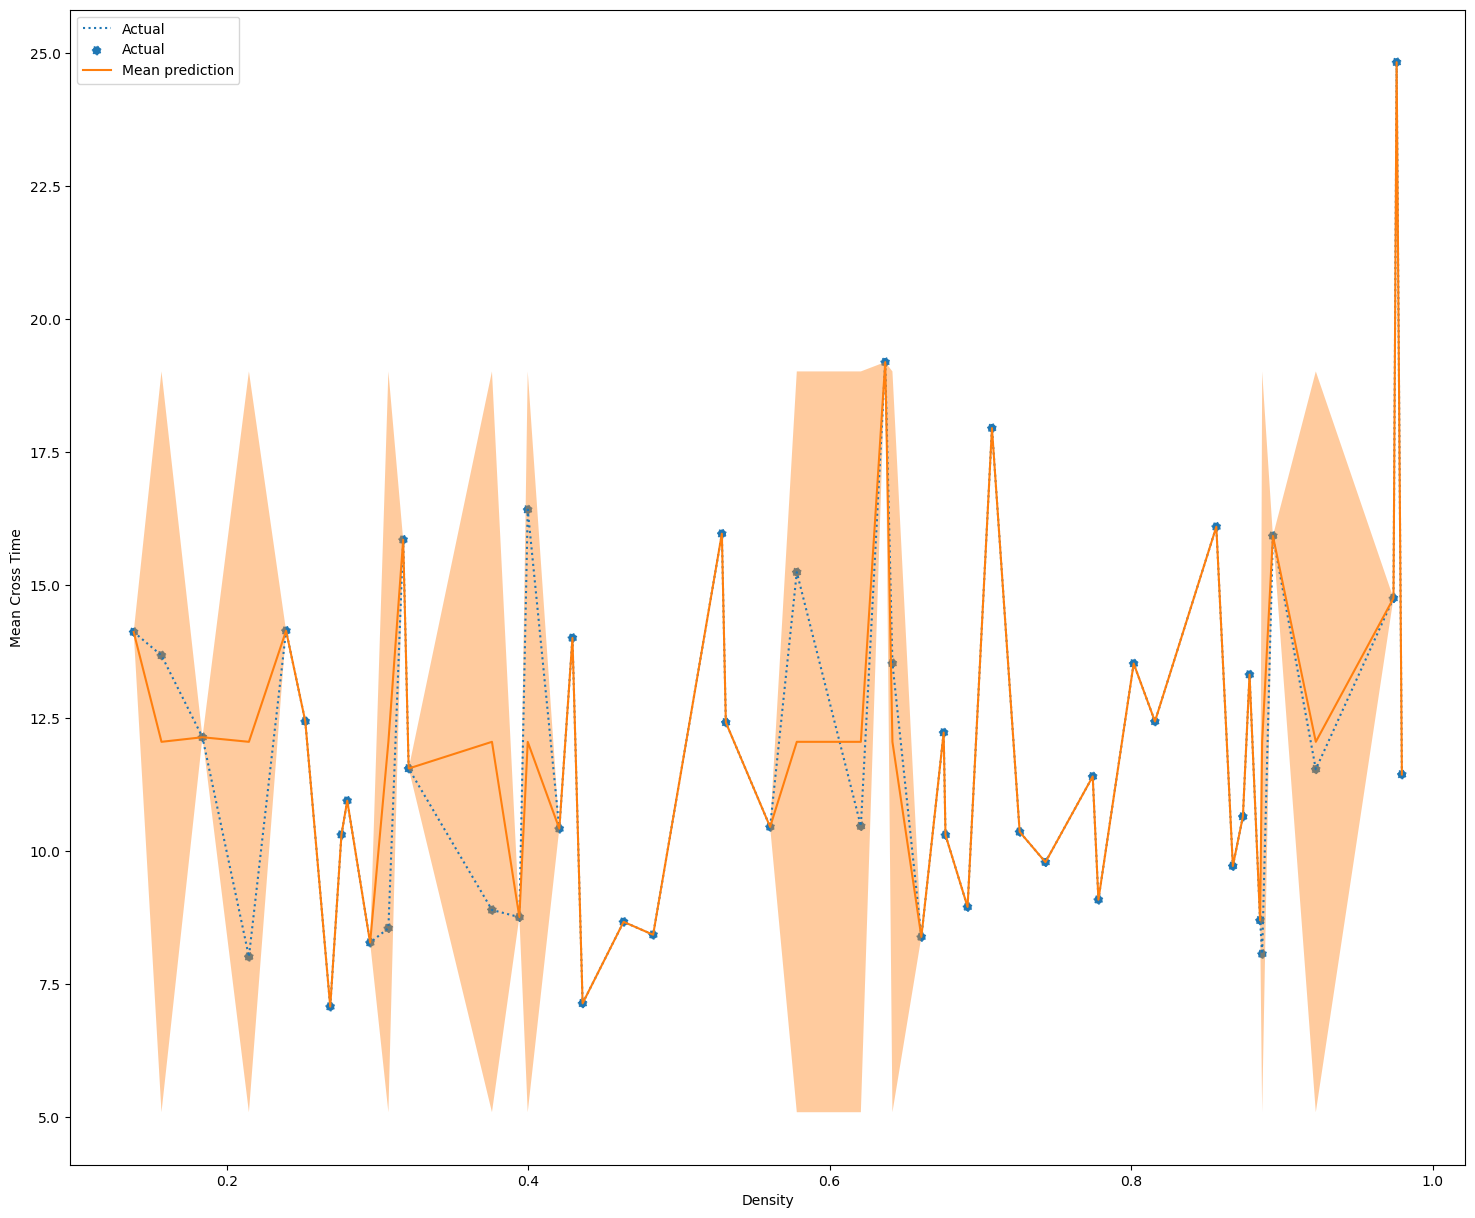

In [9]:
path = r'D:\KIT\Datasets\cafm_lhs_300.npz'

data = np.load(path)
X, y = data['X'][:50], data['Y'][:50]
#print(X)
mean_cross_time_idx = 0
density_idx = 4
y_mean_cross_time = y[:, mean_cross_time_idx]

x_density = X[:,density_idx]
mean_point = np.mean(X, axis= 0)

print(mean_point)
X_sweep = np.tile(mean_point, (50,1))

X_sweep[:,4] = x_density

scale_x = StandardScaler()
scale_y = StandardScaler()

x_train_raw, x_test_raw, y_train, y_test = train_test_split(X_sweep, y_mean_cross_time, test_size=0.2, random_state=42)


x_train_scale = scale_x.fit_transform(x_train_raw)
y_train_scale = scale_y.fit_transform(y_train.reshape(-1,1)).ravel()
x_test_scale = scale_x.transform(x_test_raw)


kernel = 1*Matern(length_scale=1.0, length_scale_bounds=(1e-10, 15), nu = 2.5)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(x_train_scale, y_train_scale)
print(gaussian_process.kernel_)

X_sweep_scale = scale_x.transform(X_sweep)

mean_pre, std_pre = gaussian_process.predict(X_sweep_scale, return_std= True)
mean_pre_real = scale_y.inverse_transform(mean_pre.reshape(-1, 1)).ravel()
std_pre_real = std_pre * scale_y.scale_[0]

lower_bound = mean_pre_real - 1.96 * std_pre_real
upper_bound = mean_pre_real + 1.96 * std_pre_real


idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(18,15))
plt.plot(X_sweep[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.scatter(X_sweep[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.plot(X_sweep[idx, density_idx], mean_pre_real[idx], label="Mean prediction")

plt.fill_between(
    X_sweep[idx, density_idx],
    lower_bound[idx],
    upper_bound[idx],
    alpha=0.4
)

plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()




## full 6D train then mean fixed

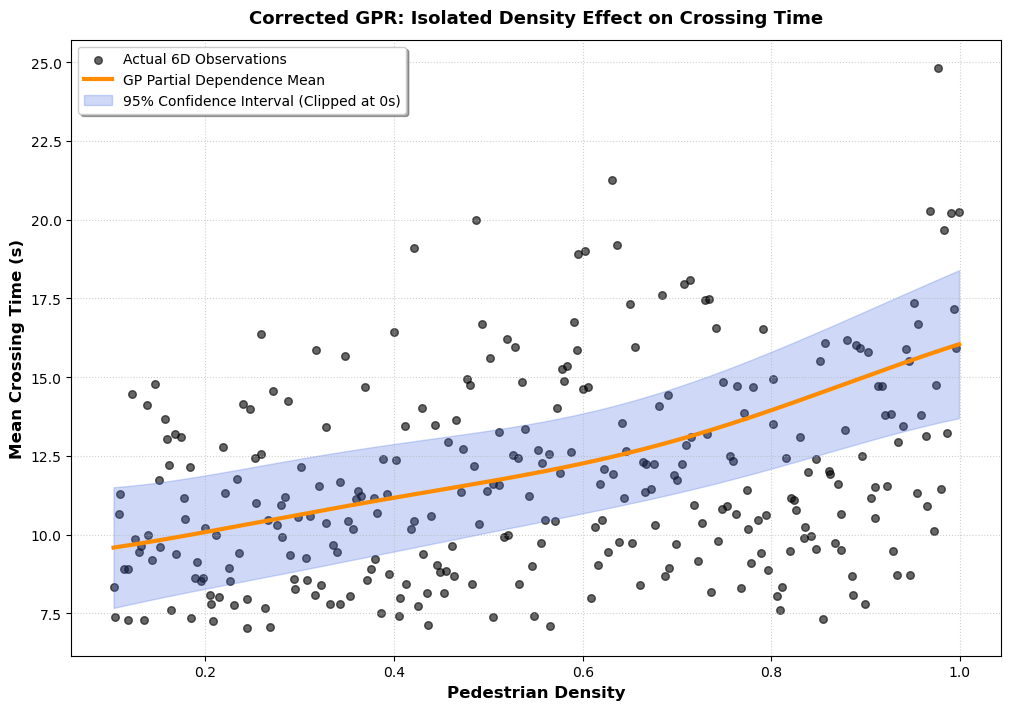

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

path = r'D:\KIT\cafm_lhs_300.npz'
data = np.load(path)
X, y = data['X'], data['Y']

mean_cross_time_idx = 0
density_idx = 4
y_mean_cross_time = y[:, mean_cross_time_idx]

x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    X, y_mean_cross_time, test_size=0.2, random_state=42
)
scale_x = StandardScaler()
scale_y = StandardScaler()

x_train_scale = scale_x.fit_transform(x_train_raw)
y_train_scale = scale_y.fit_transform(y_train.reshape(-1, 1)).ravel()
x_test_scale = scale_x.transform(x_test_raw)

kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(6), length_scale_bounds=(0.1, 15), nu=2.5)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=7, random_state=42)
gaussian_process.fit(x_train_scale, y_train_scale)

mean_point = np.mean(X, axis=0)

x_density_raw = X[:, density_idx]

X_sweep = np.tile(mean_point, (300, 1))
X_sweep[:, density_idx] = x_density_raw

X_sweep_scale = scale_x.transform(X_sweep)
mean_pre, std_pre = gaussian_process.predict(X_sweep_scale, return_std=True)

mean_prediction_real = scale_y.inverse_transform(mean_pre.reshape(-1, 1)).ravel()
std_prediction_real = std_pre * scale_y.scale_[0]

lower_bound_clipped = np.clip(mean_prediction_real - 1.96 * std_prediction_real, 0, None)
upper_bound = mean_prediction_real + 1.96 * std_prediction_real


idx_sort = np.argsort(x_density_raw)

plt.figure(figsize=(12, 8))

plt.scatter(X[:, density_idx], y_mean_cross_time, color='black', alpha=0.6, s=30, label='Actual 6D Observations')

plt.plot(x_density_raw[idx_sort], mean_prediction_real[idx_sort], color='darkorange', lw=3, label='GP Partial Dependence Mean')
plt.fill_between(
    x_density_raw[idx_sort],
    lower_bound_clipped[idx_sort],
    upper_bound[idx_sort],
    color='royalblue',
    alpha=0.25,
    label='95% Confidence Interval (Clipped at 0s)'
)

plt.xlabel(r"Pedestrian Density", fontsize=12, fontweight='bold')
plt.ylabel("Mean Crossing Time (s)", fontsize=12, fontweight='bold')
plt.title("Corrected GPR: Isolated Density Effect on Crossing Time", fontsize=13, fontweight='bold', pad=12)
plt.legend(frameon=True, shadow=True, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# **Monte Carlo fitting**

### GP on (Density+freeze) to 1D

[[1.14482358e+00 7.07183986e-01 3.41923830e+01 8.42765348e-01
  3.68145308e-01 4.19938999e-01]
 [1.52979330e+00 3.86579420e-01 1.75663846e+01 1.35465057e+00
  8.99578430e-01 1.84970481e-01]
 [1.21086753e+00 5.64453208e-01 3.08841316e+01 1.11619499e+00
  6.92009653e-01 9.90381557e-03]
 [8.14515533e-01 5.40784676e-01 1.71292136e+01 1.48121484e+00
  1.25693166e-01 2.74691136e-01]
 [9.13177247e-01 6.35810105e-01 2.17825037e+01 1.51508138e+00
  3.02752343e-01 4.80117924e-01]
 [1.31220868e+00 4.71394510e-01 3.74709996e+01 1.07501033e+00
  6.29125650e-01 2.42952641e-01]
 [1.42845215e+00 7.94043800e-01 1.29059990e+01 1.23850786e+00
  8.78856234e-01 7.76531179e-02]
 [1.04616188e+00 3.01686312e-01 2.75984199e+01 9.51577733e-01
  5.02987746e-01 3.40731967e-01]
 [1.05456259e+00 5.99979843e-01 1.12481158e+01 1.00265323e+00
  9.68785662e-01 2.93402962e-01]
 [1.47083265e+00 4.98675069e-01 2.55010673e+01 1.58763377e+00
  4.10105528e-01 6.16351408e-02]
 [1.38857967e+00 7.03403981e-01 2.39313672e+01 9.2

c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


1.88**2 * Matern(length_scale=0.1, nu=2.5)


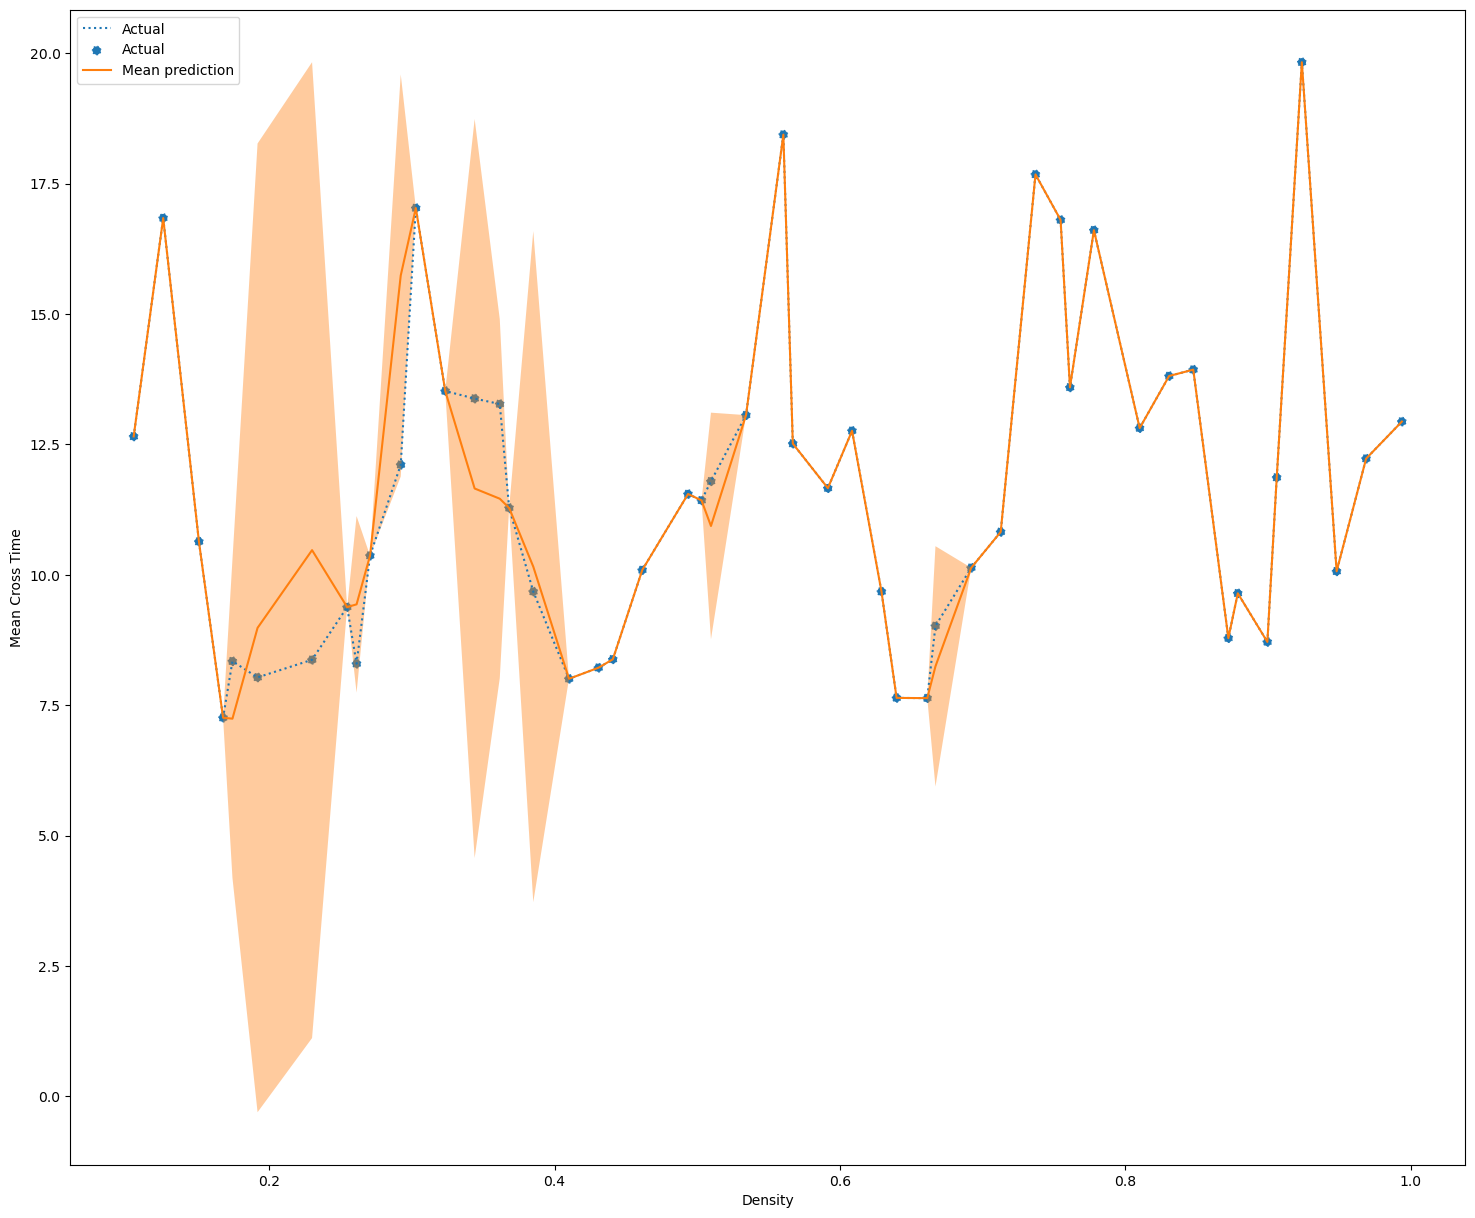

In [91]:
path = r'D:\KIT\cafm_qmc_256.npz'

data = np.load(path)
X, y = data['X'][:50], data['Y'][:50]
print(X)
mean_cross_time_idx = 0
density_idx = 4
y_mean_cross_time = y[:, mean_cross_time_idx]

x_density = X[:,density_idx]
mean_point = np.mean(X, axis= 0)

print(mean_point)
X_sweep = np.tile(mean_point, (50,1))

X_sweep[:,4] = x_density

scale_x = StandardScaler()
scale_y = StandardScaler()

x_train_raw, x_test_raw, y_train, y_test = train_test_split(X_sweep, y_mean_cross_time, test_size=0.2, random_state=42)


x_train_scale = scale_x.fit_transform(x_train_raw)
y_train_scale = scale_y.fit_transform(y_train.reshape(-1,1)).ravel()
x_test_scale = scale_x.transform(x_test_raw)


kernel = 1*Matern(length_scale=1.0, length_scale_bounds=(0.1, 15), nu = 2.5)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=7)
gaussian_process.fit(x_train_scale, y_train_scale)
print(gaussian_process.kernel_)

X_sweep_scale = scale_x.transform(X_sweep)

mean_pre, std_pre = gaussian_process.predict(X_sweep_scale, return_std= True)
mean_pre_real = scale_y.inverse_transform(mean_pre.reshape(-1, 1)).ravel()
std_pre_real = std_pre * scale_y.scale_[0]

lower_bound = mean_pre_real - 1.96 * std_pre_real
upper_bound = mean_pre_real + 1.96 * std_pre_real


idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(18,15))
plt.plot(X_sweep[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.scatter(X_sweep[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.plot(X_sweep[idx, density_idx], mean_pre_real[idx], label="Mean prediction")


plt.fill_between(
    X_sweep[idx, density_idx],
    lower_bound[idx],
    upper_bound[idx],
    alpha=0.4
)

plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()

## Using RBF/Matern kernel (GP - 6D and plot 1D) - Monte Carlo

In [92]:
data_path = r'D:\KIT\cafm_qmc_256.npz'
data = np.load(data_path)
X, Y = data['X'][:50], data['Y'][:50]
print(X)
mean_cross_time_idx = 0
density_idx = 4

# X_density = X[:,density_idx]
y_mean_cross_time = Y[:, mean_cross_time_idx]

x_train_raw, x_test_raw, y_train, y_test = train_test_split(X, y_mean_cross_time, test_size= 0.2, random_state=42)

scale_x = StandardScaler()
scale_y = StandardScaler()

x_train = scale_x.fit_transform(x_train_raw)
x_test = scale_x.transform(x_test_raw)
y_train = scale_y.fit_transform(y_train.reshape(-1,1)).ravel()

# kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-1, 15.0), nu=2.5)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=7)
gaussian_process.fit(x_train, y_train)
gaussian_process.kernel_



[[1.14482358e+00 7.07183986e-01 3.41923830e+01 8.42765348e-01
  3.68145308e-01 4.19938999e-01]
 [1.52979330e+00 3.86579420e-01 1.75663846e+01 1.35465057e+00
  8.99578430e-01 1.84970481e-01]
 [1.21086753e+00 5.64453208e-01 3.08841316e+01 1.11619499e+00
  6.92009653e-01 9.90381557e-03]
 [8.14515533e-01 5.40784676e-01 1.71292136e+01 1.48121484e+00
  1.25693166e-01 2.74691136e-01]
 [9.13177247e-01 6.35810105e-01 2.17825037e+01 1.51508138e+00
  3.02752343e-01 4.80117924e-01]
 [1.31220868e+00 4.71394510e-01 3.74709996e+01 1.07501033e+00
  6.29125650e-01 2.42952641e-01]
 [1.42845215e+00 7.94043800e-01 1.29059990e+01 1.23850786e+00
  8.78856234e-01 7.76531179e-02]
 [1.04616188e+00 3.01686312e-01 2.75984199e+01 9.51577733e-01
  5.02987746e-01 3.40731967e-01]
 [1.05456259e+00 5.99979843e-01 1.12481158e+01 1.00265323e+00
  9.68785662e-01 2.93402962e-01]
 [1.47083265e+00 4.98675069e-01 2.55010673e+01 1.58763377e+00
  4.10105528e-01 6.16351408e-02]
 [1.38857967e+00 7.03403981e-01 2.39313672e+01 9.2

1.25**2 * Matern(length_scale=2.94, nu=2.5)

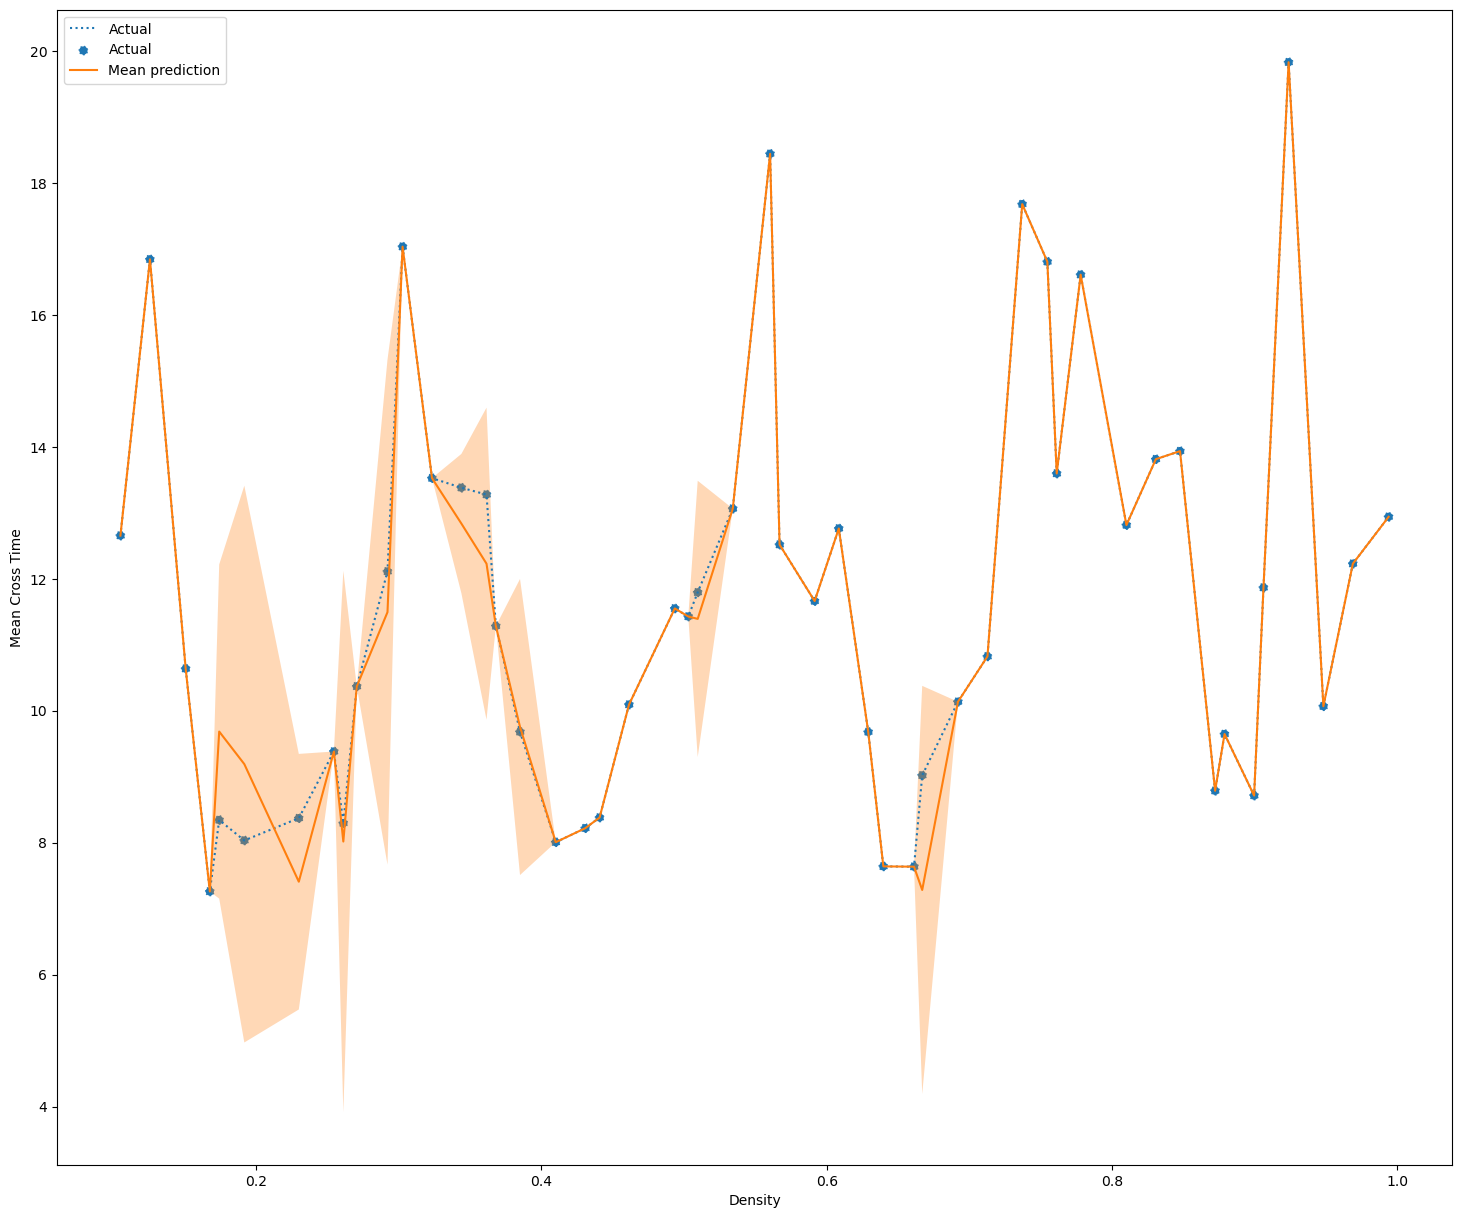

In [93]:
X_scaled = scale_x.transform(X)
mean_prediction, std_prediction = gaussian_process.predict(X_scaled, return_std=True)

idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(18,15))
plt.plot(X[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.scatter(X[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.plot(X[idx, density_idx], scale_y.inverse_transform(mean_prediction.reshape(-1,1)).ravel()[idx], label="Mean prediction")

plt.fill_between(
    X[idx, density_idx],
    scale_y.inverse_transform(
        (mean_prediction - 1.96*std_prediction).reshape(-1,1)
    ).ravel()[idx],
    scale_y.inverse_transform(
        (mean_prediction + 1.96*std_prediction).reshape(-1,1)
    ).ravel()[idx],
    alpha=0.3
)

plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()

## Now taking Data have noise

### # Now freezing other parameters at there mean

[ 1.20349139  0.58022977 24.74804243  1.20091215  0.57594661  0.24946933]
0.991**2 * Matern(length_scale=0.00516, nu=2.5) + WhiteKernel(noise_level=1.04e-05)


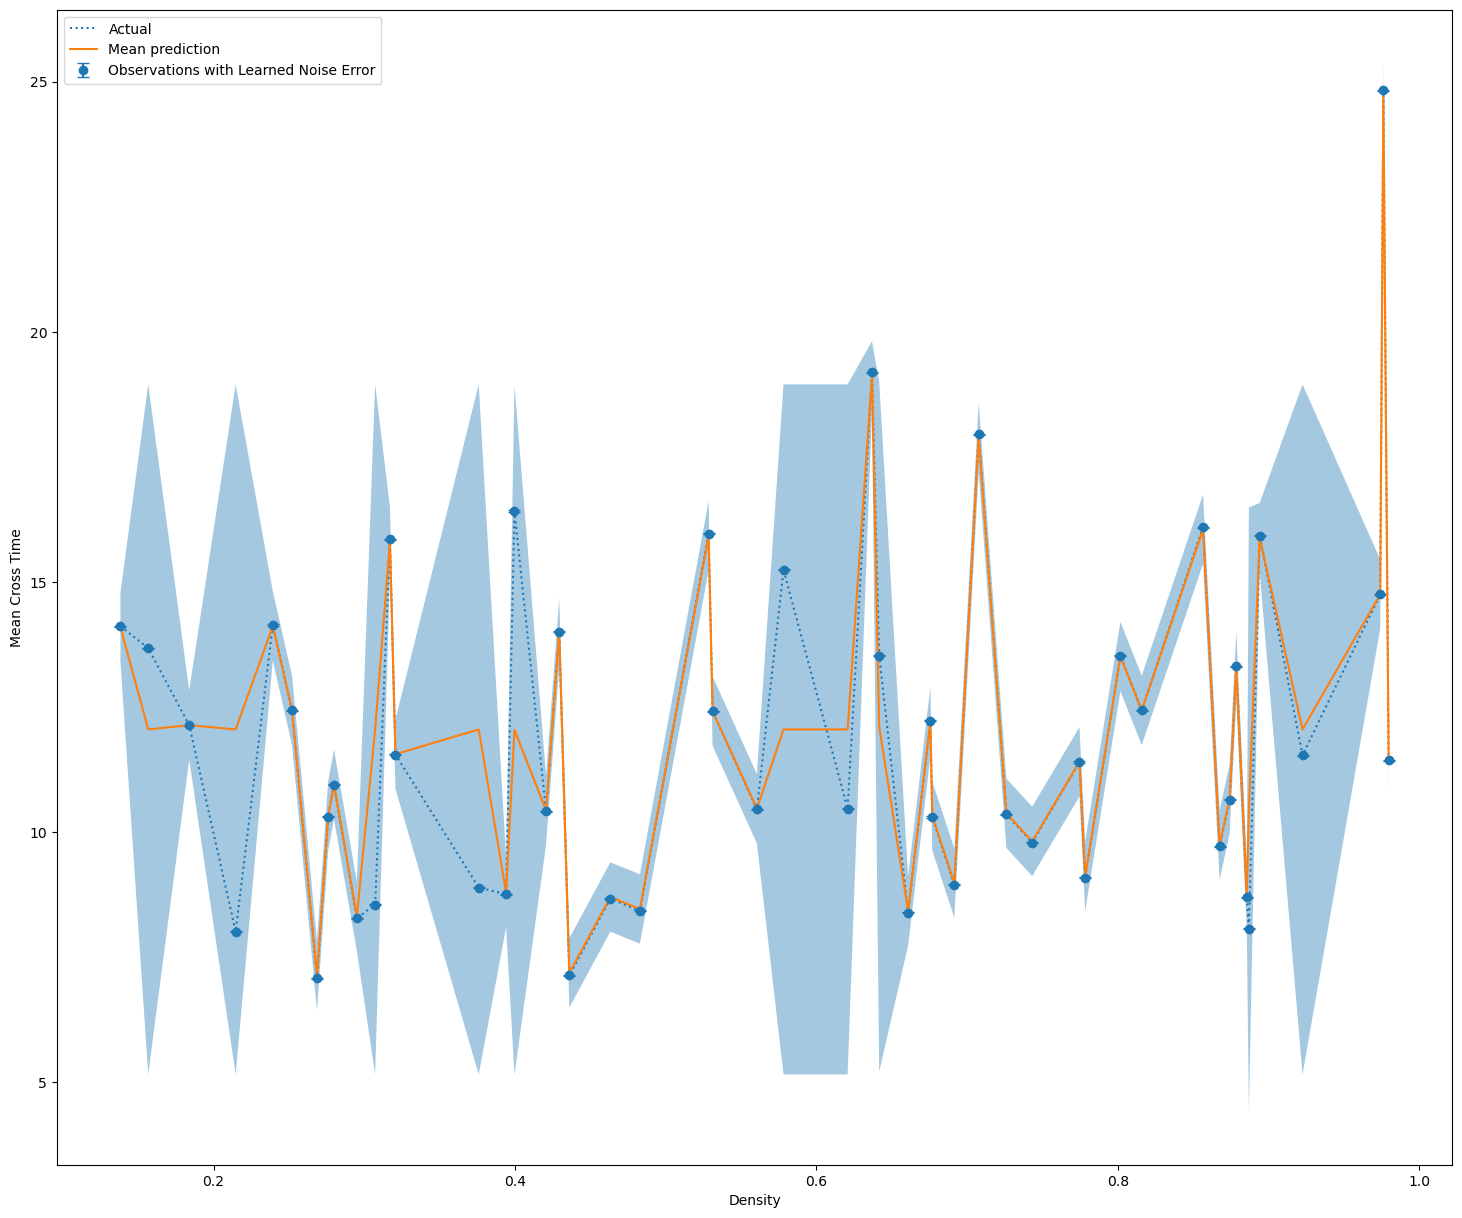

In [5]:
path = r'D:\KIT\cafm_lhs_300.npz'

data = np.load(path)
X, y = data['X'][:50], data['Y'][:50]
#print(X)
mean_cross_time_idx = 0
density_idx = 4
y_mean_cross_time = y[:, mean_cross_time_idx]

x_density = X[:,density_idx]
mean_point = np.mean(X, axis= 0)

print(mean_point)
X_sweep = np.tile(mean_point, (50,1))

X_sweep[:,4] = x_density

scale_x = StandardScaler()
scale_y = StandardScaler()

x_train_raw, x_test_raw, y_train, y_test = train_test_split(X_sweep, y_mean_cross_time, test_size=0.2, random_state=42)


x_train_scale = scale_x.fit_transform(x_train_raw)
y_train_scale = scale_y.fit_transform(y_train.reshape(-1,1)).ravel()
x_test_scale = scale_x.transform(x_test_raw)


kernel = 1*Matern(length_scale=1.0, length_scale_bounds=(1e-10, 15), nu = 2.5) + WhiteKernel(noise_level=1.0)
gaussian_process = GaussianProcessRegressor(kernel= kernel, alpha=1e-2, n_restarts_optimizer=9)

gaussian_process.fit(x_train_scale, y_train_scale)
print(gaussian_process.kernel_)

X_sweep_scale = scale_x.transform(X_sweep)

mean_pre, std_pre = gaussian_process.predict(X_sweep_scale, return_std= True)
mean_pre_real = scale_y.inverse_transform(mean_pre.reshape(-1, 1)).ravel()
std_pre_real = std_pre * scale_y.scale_[0]

lower_bound = mean_pre_real - 1.96 * std_pre_real
upper_bound = mean_pre_real + 1.96 * std_pre_real


# 1. Scaled Variance nikaalo (e.g., model ne bola noise_level = 0.04)
learned_noise_var_scaled = gaussian_process.kernel_.k2.noise_level
# 2. Formula lagao: pehle sqrt kiya (0.2), fir seconds ke scale se multiply kiya
noise_std_seconds = np.sqrt(learned_noise_var_scaled) * scale_y.scale_[0]


idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(18,15))
plt.plot(X_sweep[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.errorbar(X_sweep[:, density_idx], y_mean_cross_time, yerr=noise_std_seconds, linestyle="None", color="tab:blue", marker=".", markersize=12, capsize=4, label="Observations with Learned Noise Error")
plt.plot(X_sweep[idx, density_idx], mean_pre_real[idx], label="Mean prediction")

plt.fill_between(
    X_sweep[idx, density_idx],
    lower_bound[idx],
    upper_bound[idx],
    alpha=0.4
)

plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()


## **Monte Carlo datapoints with noise kernel**

[ 1.20650772  0.55004614 24.97911648  1.19519841  0.54663756  0.25178945]
0.835**2 * Matern(length_scale=0.0683, nu=2.5) + WhiteKernel(noise_level=0.279)


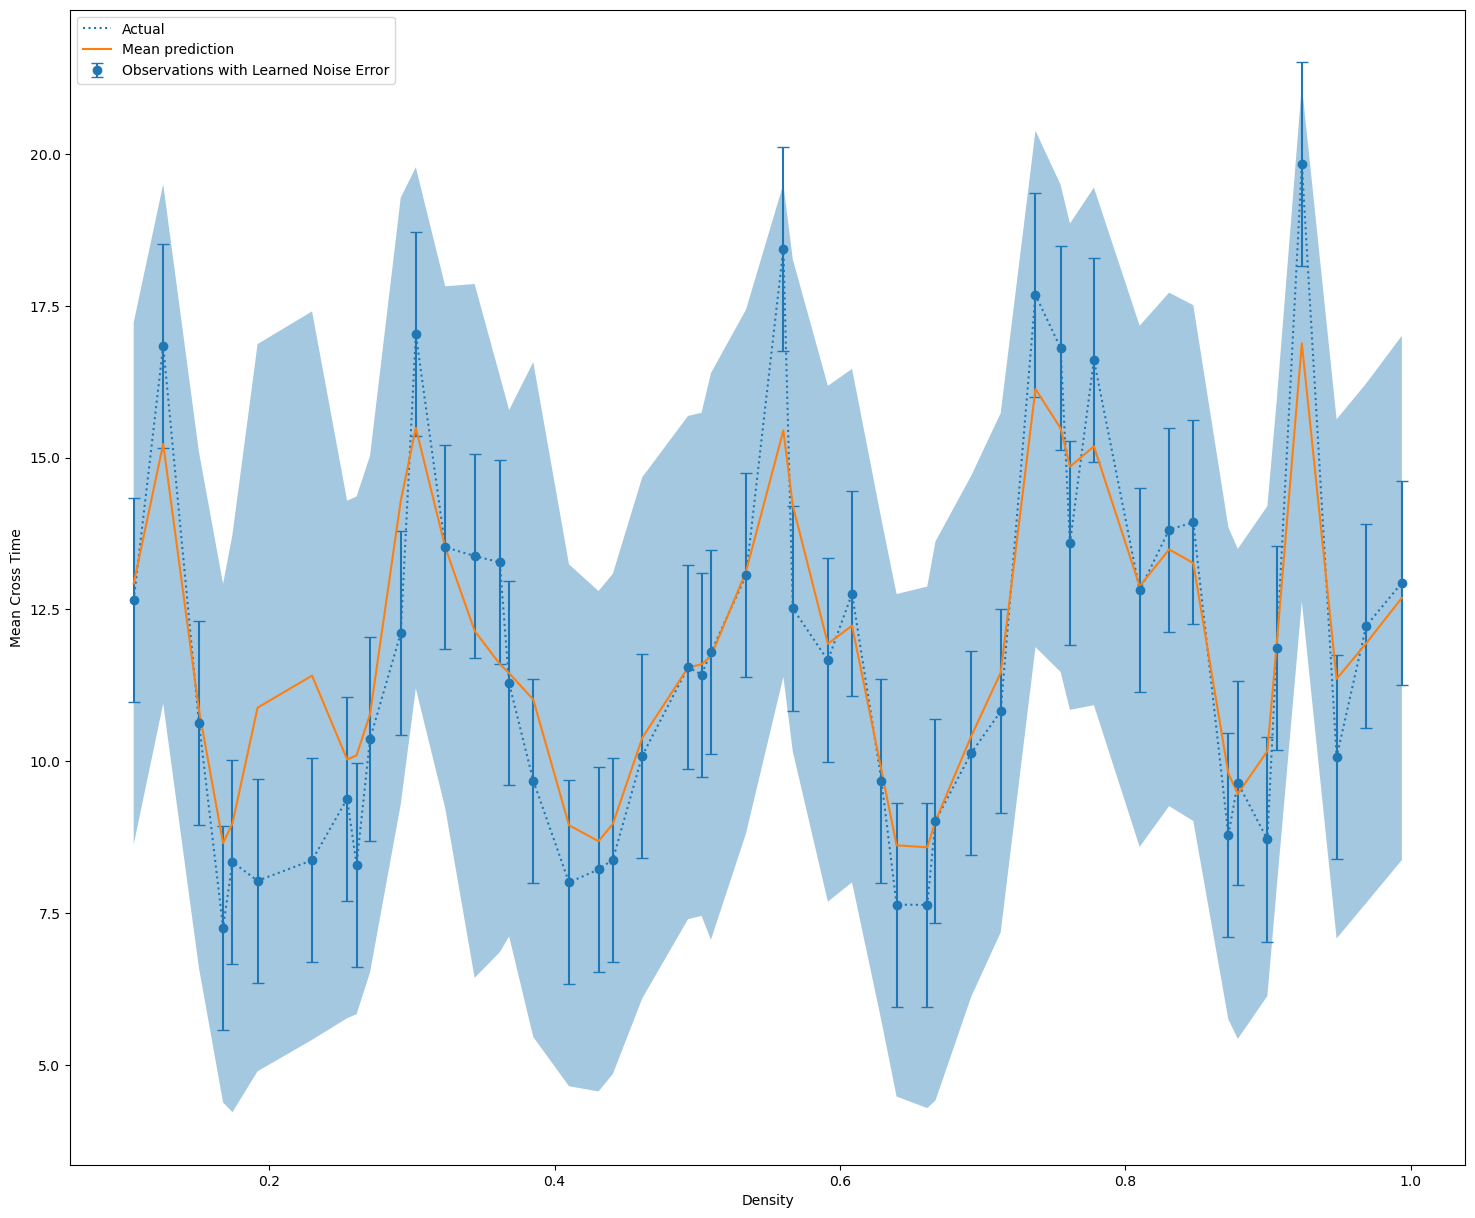

In [6]:
path = r'D:\KIT\cafm_qmc_256.npz'

data = np.load(path)
X, y = data['X'][:50], data['Y'][:50]
#print(X)
mean_cross_time_idx = 0
density_idx = 4
y_mean_cross_time = y[:, mean_cross_time_idx]

x_density = X[:,density_idx]
mean_point = np.mean(X, axis= 0)

print(mean_point)
X_sweep = np.tile(mean_point, (50,1))

X_sweep[:,4] = x_density

scale_x = StandardScaler()
scale_y = StandardScaler()

x_train_raw, x_test_raw, y_train, y_test = train_test_split(X_sweep, y_mean_cross_time, test_size=0.2, random_state=42)


x_train_scale = scale_x.fit_transform(x_train_raw)
y_train_scale = scale_y.fit_transform(y_train.reshape(-1,1)).ravel()
x_test_scale = scale_x.transform(x_test_raw)


kernel = 1*Matern(length_scale=1.0, length_scale_bounds=(1e-10, 15), nu = 2.5) + WhiteKernel(noise_level=1.0)
gaussian_process = GaussianProcessRegressor(kernel= kernel, alpha=1e-2, n_restarts_optimizer=19)

gaussian_process.fit(x_train_scale, y_train_scale)
print(gaussian_process.kernel_)

X_sweep_scale = scale_x.transform(X_sweep)

mean_pre, std_pre = gaussian_process.predict(X_sweep_scale, return_std= True)
mean_pre_real = scale_y.inverse_transform(mean_pre.reshape(-1, 1)).ravel()
std_pre_real = std_pre * scale_y.scale_[0]

lower_bound = mean_pre_real - 1.96 * std_pre_real
upper_bound = mean_pre_real + 1.96 * std_pre_real


# 1. Scaled Variance nikaalo (e.g., model ne bola noise_level = 0.04)
learned_noise_var_scaled = gaussian_process.kernel_.k2.noise_level
# 2. Formula lagao: pehle sqrt kiya (0.2), fir seconds ke scale se multiply kiya
noise_std_seconds = np.sqrt(learned_noise_var_scaled) * scale_y.scale_[0]


idx = np.argsort(X[:, density_idx])

plt.figure(figsize=(18,15))
plt.plot(X_sweep[idx, density_idx], y_mean_cross_time[idx], linestyle = 'dotted', label = 'Actual')
plt.errorbar(X_sweep[:, density_idx], y_mean_cross_time, yerr=noise_std_seconds, linestyle="None", color="tab:blue", marker=".", markersize=12, capsize=4, label="Observations with Learned Noise Error")
plt.plot(X_sweep[idx, density_idx], mean_pre_real[idx], label="Mean prediction")

plt.fill_between(
    X_sweep[idx, density_idx],
    lower_bound[idx],
    upper_bound[idx],
    alpha=0.4
)

plt.xlabel("Density")
plt.ylabel("Mean Cross Time")
plt.legend()
plt.show()


### Actual Partial Dependency analysis

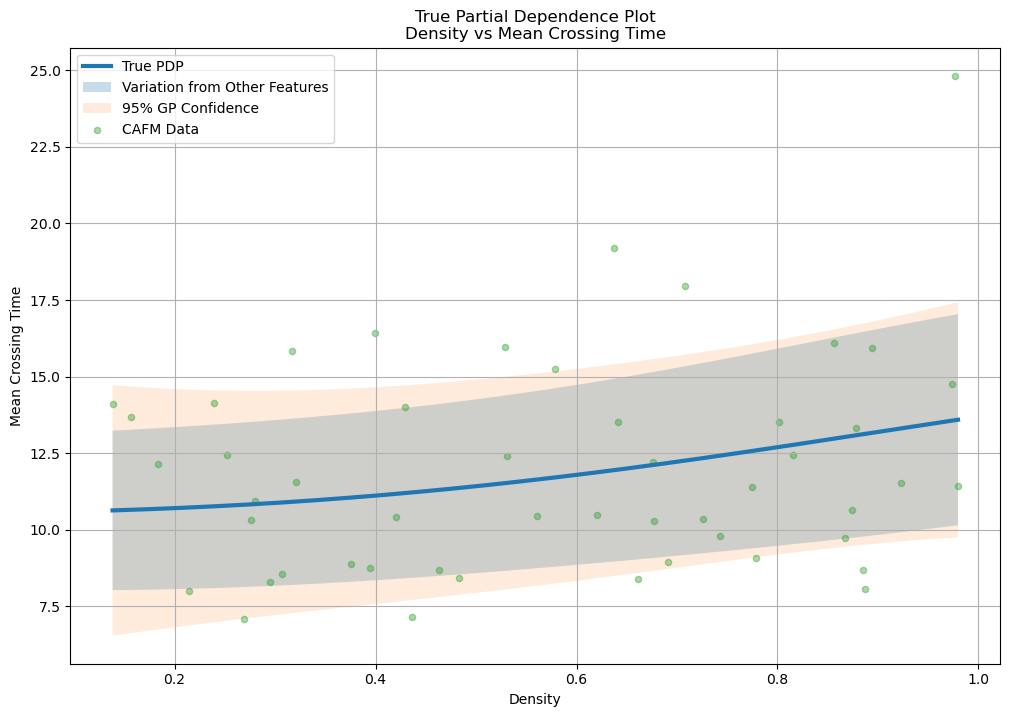

In [6]:
import numpy as np

data = np.load(r'D:\KIT\Datasets\cafm_lhs_300.npz')

X = data['X'][:50]
Y = data['Y'][:50]

target_idx = 0

y = Y[:, target_idx]

valid_mask = ~np.isnan(y)

X_clean = X[valid_mask]
y_clean = y[valid_mask]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean,test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()

kernel = 1.0*Matern(length_scale=np.ones(X.shape[1]), nu=2.5)+ WhiteKernel()

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,random_state=42)

gp.fit(X_train_scaled,y_train_scaled)

# partial dependency
density_idx = 4

density_grid = np.linspace(
    X_clean[:, density_idx].min(),
    X_clean[:, density_idx].max(),
    150
)


# density_grid = X_test[:,density_idx]


pdp_mean = []
pdp_spread = []
pdp_gp_std = []

for density in density_grid:

    X_temp = X_clean.copy()

    X_temp[:, density_idx] = density

    X_temp_scaled = scaler_X.transform(X_temp)

    pred_scaled, pred_std_scaled = gp.predict(X_temp_scaled,return_std=True)

    pred = scaler_y.inverse_transform( pred_scaled.reshape(-1,1)).ravel()

    pred_std = pred_std_scaled * scaler_y.scale_[0]

    pdp_mean.append(np.mean(pred))

    pdp_spread.append(np.std(pred))

    pdp_gp_std.append(np.sqrt(np.mean(pred_std**2)))

pdp_mean = np.array(pdp_mean)
pdp_spread = np.array(pdp_spread)
pdp_gp_std = np.array(pdp_gp_std)




plt.figure(figsize=(12,8))

# True PDP

plt.plot(
    density_grid,
    pdp_mean,
    linewidth=3,
    label='True PDP'
)

# Physical variability

plt.fill_between(
    density_grid,
    pdp_mean - pdp_spread,
    pdp_mean + pdp_spread,
    alpha=0.25,
    label='Variation from Other Features'
)

# GP uncertainty

plt.fill_between(
    density_grid,
    pdp_mean - 2*pdp_gp_std,
    pdp_mean + 2*pdp_gp_std,
    alpha=0.15,
    label='95% GP Confidence'
)

# Original CAFM samples

plt.scatter(
    X_clean[:, density_idx],
    y_clean,
    s=20,
    alpha=0.4,
    label='CAFM Data'
)

plt.xlabel('Density')
plt.ylabel('Mean Crossing Time')

plt.title(
    'True Partial Dependence Plot\nDensity vs Mean Crossing Time'
)

plt.legend()
plt.grid(True)

plt.show()

## studing the dataset and taking variance of it

Optimised kernel: 2.45**2 * Matern(length_scale=0.1, nu=2.5)
Log-marginal LML: -150.0756
RMSE: 3.9635, MAE: 2.9124


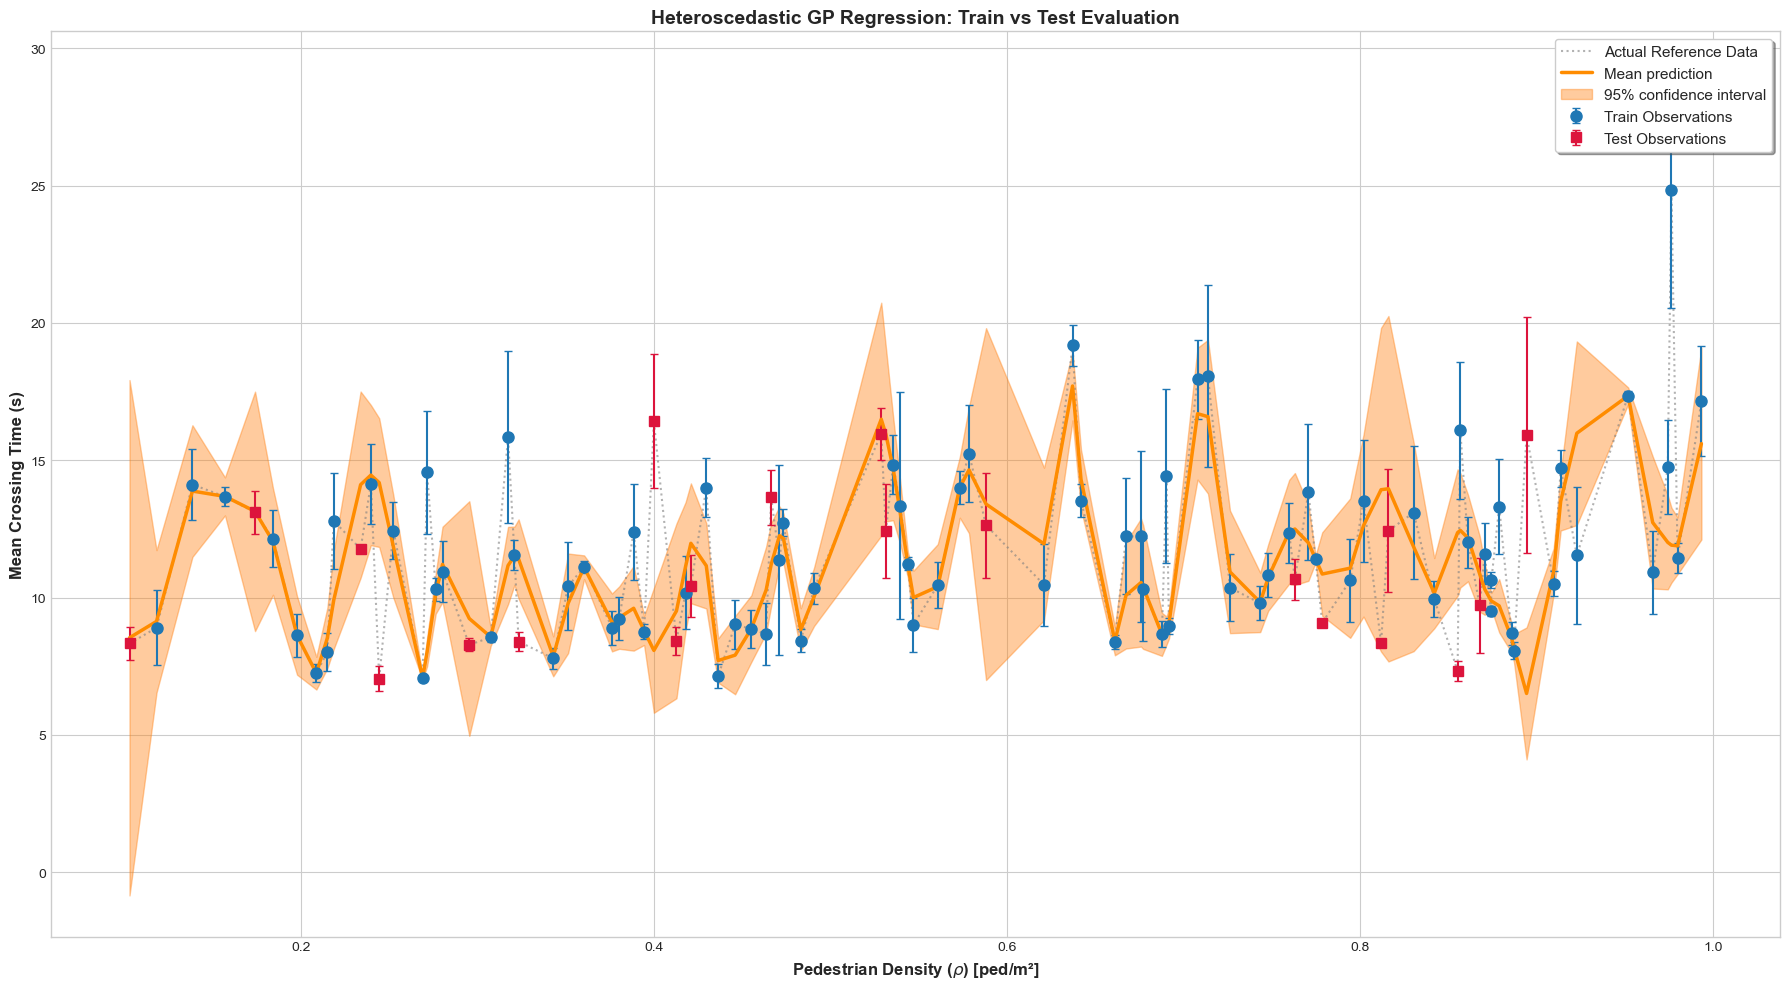

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

# ── CONFIG ──────────────────────────────────────────────
DATA_PATH    = r"D:\KIT\Datasets\cafm_lhs_300.npz"
N_POINTS     = 200
SWEEP_PARAM  = "density"        # which input to vary
TARGET_IDX   = 0                # output column
KERNEL_NAME  = "Matern-2.5"
LENGTH_SCALE = 1.0
USE_WHITE    = False
NOISE_LEVEL  = 0.01
N_RESTARTS   = 5
RANDOM_STATE = 42
TEST_SIZE    = 0.2

PARAM_NAMES  = ["v0_mean","tau","A","R_safety","density","flow_ratio"]
PARAM_BOUNDS = {
    "v0_mean"   : (0.80, 1.60),
    "tau"       : (0.30, 0.80),
    "A"         : (10.0, 40.0),
    "R_safety"  : (0.80, 1.60),
    "density"   : (0.10, 1.00),
    "flow_ratio": (0.00, 0.50),
}
OUTPUT_NAMES = ["mean_crossing_time","flow_rate","order_param_mean","mean_speed"]

# ── 1. Load data ────────────────────────────────────────
data = np.load(DATA_PATH)
X = data["X"][:N_POINTS]
y_all = data["Y"][:N_POINTS, TARGET_IDX]
y_std_all = data["Y_std"][:N_POINTS, TARGET_IDX]

# ── 2. Random freeze point ─────────────────────────────
rng = np.random.default_rng(RANDOM_STATE)
freeze_point = np.array([rng.uniform(*PARAM_BOUNDS[p]) for p in PARAM_NAMES])

# ── 3. Sort by sweep parameter ─────────────────────────
sweep_idx = PARAM_NAMES.index(SWEEP_PARAM)
sort_idx = np.argsort(X[:, sweep_idx])
sweep_vals = X[sort_idx, sweep_idx]          # sorted sweep values
y_sorted = y_all[sort_idx]                   # sorted targets
y_std_sorted = y_std_all[sort_idx]           # sorted stds

N = len(X)
X_sweep = np.tile(freeze_point, (N, 1))
X_sweep[:, sweep_idx] = sweep_vals

# ── 4. Train / test split ──────────────────────────────
X_tr, X_te, y_tr, y_te, std_tr, std_te = train_test_split(
    X_sweep, y_sorted, y_std_sorted,
    test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ── 5. Scale ───────────────────────────────────────────
sc_x = StandardScaler()
sc_y = StandardScaler()
X_tr_s = sc_x.fit_transform(X_tr)
y_tr_s = sc_y.fit_transform(y_tr.reshape(-1,1)).ravel()
X_te_s = sc_x.transform(X_te)
X_sw_s = sc_x.transform(X_sweep)


alpha_tr_scaled = (std_tr / sc_y.scale_[0])**2

# ── 6. Kernel ──────────────────────────────────────────
if KERNEL_NAME == "Matern-2.5":
    kernel = C(1.0) * Matern(length_scale=LENGTH_SCALE, length_scale_bounds=(0.1, 15.0),  nu=2.5)
elif KERNEL_NAME == "Matern-1.5":
    kernel = C(1.0) * Matern(length_scale=LENGTH_SCALE, length_scale_bounds=(0.1, 15.0), nu=1.5)
else:
    kernel = C(1.0) * Matern(length_scale=LENGTH_SCALE, length_scale_bounds=(0.1, 15.0), nu=2.5)  # default

if USE_WHITE:
    kernel += WhiteKernel(noise_level=NOISE_LEVEL)

# ── 7. Fit GP with per‑point noise ─────────────────────
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=alpha_tr_scaled,                 
    n_restarts_optimizer=N_RESTARTS
)
gp.fit(X_tr_s, y_tr_s)
print(f"Optimised kernel: {gp.kernel_}")
print(f"Log-marginal LML: {gp.log_marginal_likelihood_value_:.4f}")

# ── 8. Predict ─────────────────────────────────────────
# Full sweep
mean_s, std_s = gp.predict(X_sw_s, return_std=True)
mean_pred = sc_y.inverse_transform(mean_s.reshape(-1,1)).ravel()
std_pred  = std_s * sc_y.scale_[0]

# Test set
mean_te_s, _ = gp.predict(X_te_s, return_std=True)
mean_te = sc_y.inverse_transform(mean_te_s.reshape(-1,1)).ravel()
errors = y_te - mean_te

# ── 9. Error stats ─────────────────────────────────────
rmse = np.sqrt(np.mean(errors**2))
mae  = np.mean(np.abs(errors))
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# =====================================================================
# 10. PLOTTING (Separating Train and Test Data Visually)
# =====================================================================
plt.figure(figsize=(18, 10))

# 1. Actual background reference line
plt.plot(
    sweep_vals, 
    y_sorted, 
    label=r"Actual Reference Data", 
    linestyle="dotted",
    color="gray",
    alpha=0.6
)

# 2. Scatter plot with Error Bars (TRAIN OBSERVATIONS - Blue)
train_density_vals = X_tr[:, sweep_idx]
plt.errorbar(
    train_density_vals,
    y_tr,
    yerr=std_tr,
    linestyle="None",
    color="tab:blue",
    marker="o",
    markersize=8,
    capsize=3,
    label="Train Observations",
)

# 3. Scatter plot with Error Bars (TEST OBSERVATIONS - Red/Crimson)
test_density_vals = X_te[:, sweep_idx]
plt.errorbar(
    test_density_vals,
    y_te,
    yerr=std_te,
    linestyle="None",
    color="crimson",      # Different color for test data
    marker="s",           # Square marker to easily distinguish
    markersize=7,
    capsize=3,
    label="Test Observations",
)

# 4. GP Mean Prediction Line
plt.plot(
    sweep_vals, 
    mean_pred, 
    color="darkorange",
    linewidth=2.5,
    label="Mean prediction"
)

# 5. Confidence Interval Ribbon
plt.fill_between(
    sweep_vals,
    mean_pred - 1.96 * std_pred,
    mean_pred + 1.96 * std_pred,
    color="tab:orange",
    alpha=0.4,
    label=r"95% confidence interval",
)

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.xlabel(r"Pedestrian Density ($\rho$) [ped/m²]", fontsize=12, fontweight='bold')
plt.ylabel("Mean Crossing Time (s)", fontsize=12, fontweight='bold')
plt.title("Heteroscedastic GP Regression: Train vs Test Evaluation", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Optimised kernel: 0.661**2 * Matern(length_scale=0.1, nu=2.5)
Log-marginal LML: -104.9385
RMSE: 0.9522, MAE: 0.7202


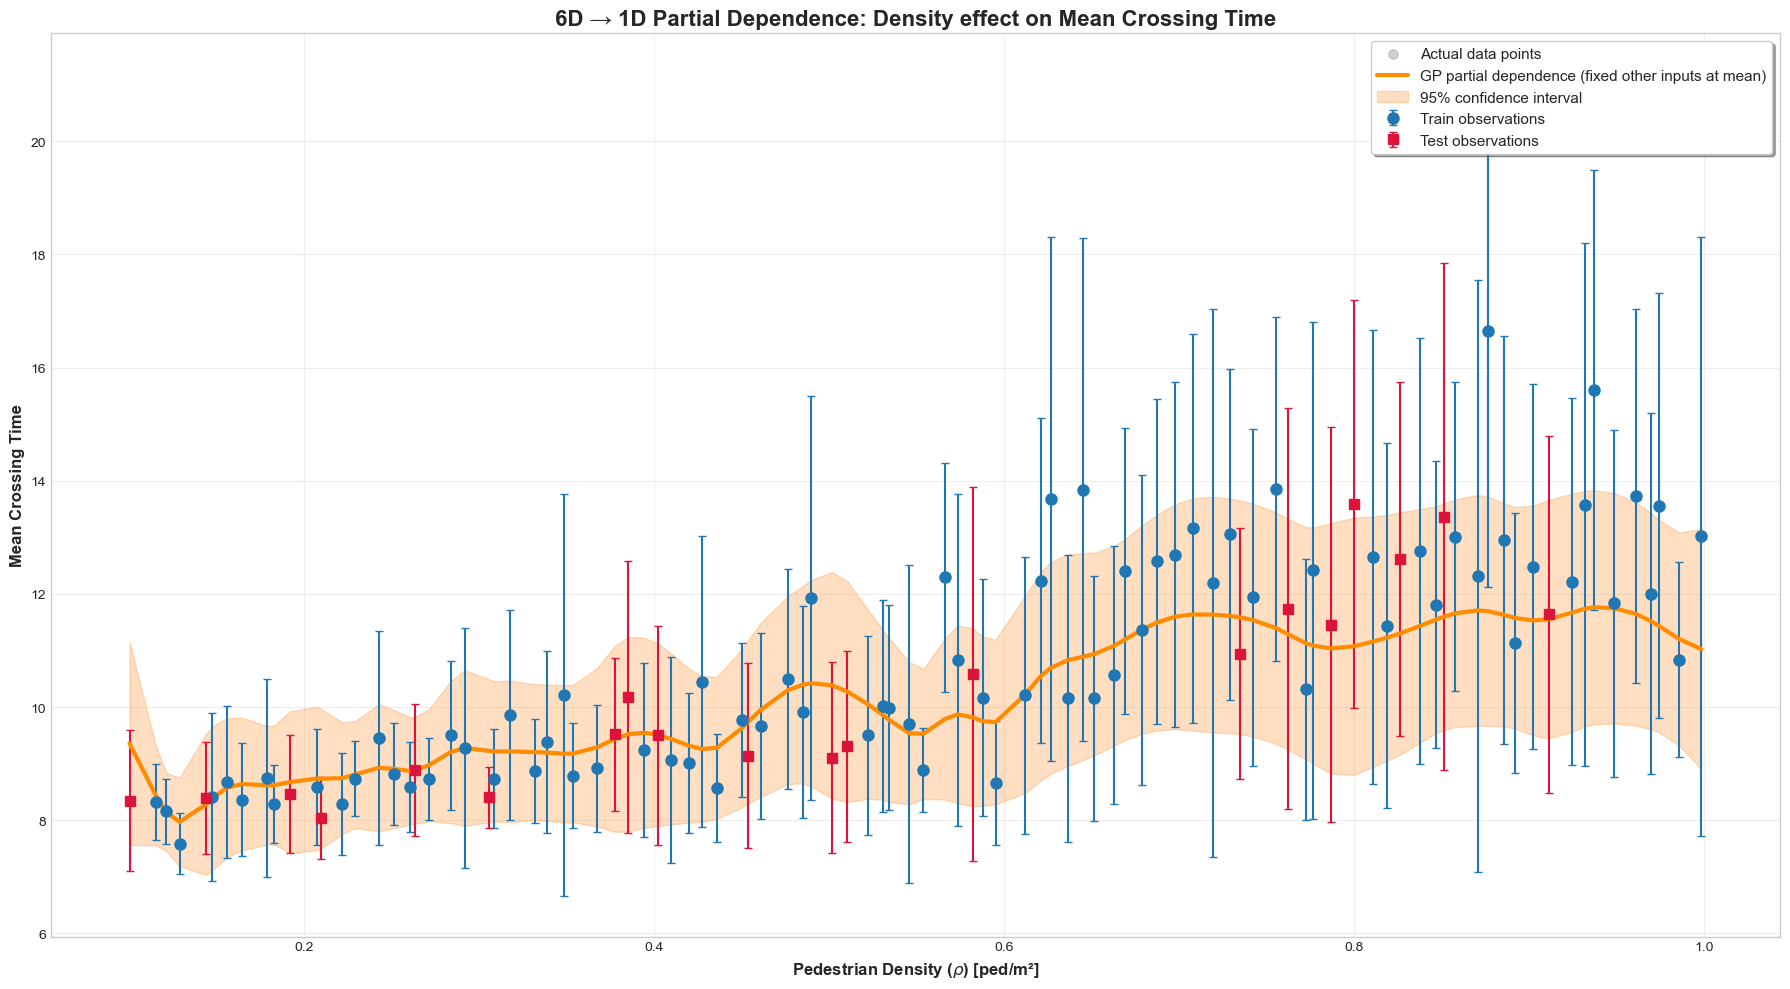

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

# ── CONFIG ──────────────────────────────────────────────
DATA_PATH    = r"D:\KIT\social_force_model\cafm_sweep_lhs_100x10.npz"   # <-- your new dataset
N_POINTS     = 100             # use all rows (or set to e.g. 20)
SWEEP_PARAM  = "density"        # must match the swept parameter in dataset
TARGET_IDX   = 0                # output column (0=mean_crossing_time)
KERNEL_NAME  = "Matern-2.5"
LENGTH_SCALE = 1.0
USE_WHITE    = False
NOISE_LEVEL  = 0.010
N_RESTARTS   = 5
RANDOM_STATE = 42
TEST_SIZE    = 0.2

PARAM_NAMES  = ["v0_mean","tau","A","R_safety","density","flow_ratio"]
PARAM_BOUNDS = {
    "v0_mean"   : (0.80, 1.60),
    "tau"       : (0.30, 0.80),
    "A"         : (10.0, 40.0),
    "R_safety"  : (0.80, 1.60),
    "density"   : (0.10, 1.00),
    "flow_ratio": (0.00, 0.50),
}
OUTPUT_NAMES = ["mean_crossing_time","flow_rate","order_param_mean","mean_speed"]

# ── 1. Load data (already a sweep over density) ────────
data = np.load(DATA_PATH)
X = data["X"]              # shape (n_points, 6)
Y = data["Y"]              # shape (n_points, 4)
Y_std = data["Y_std"]      # shape (n_points, 4)

if N_POINTS is not None:
    X = X[:N_POINTS]
    Y = Y[:N_POINTS]
    Y_std = Y_std[:N_POINTS]

y_all = Y[:, TARGET_IDX]
y_std_all = Y_std[:, TARGET_IDX]

# ── 2. Sort by the sweep parameter for clean plotting ─
sweep_idx = PARAM_NAMES.index(SWEEP_PARAM)
sort_idx = np.argsort(X[:, sweep_idx])
X_sorted = X[sort_idx]
y_sorted = y_all[sort_idx]
y_std_sorted = y_std_all[sort_idx]
sweep_vals = X_sorted[:, sweep_idx]    # density values

# ── 3. Train / test split ──────────────────────────────
X_tr, X_te, y_tr, y_te, std_tr, std_te = train_test_split(
    X_sorted, y_sorted, y_std_sorted,
    test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ── 4. Scale ───────────────────────────────────────────
sc_x = StandardScaler()
sc_y = StandardScaler()
X_tr_s = sc_x.fit_transform(X_tr)
y_tr_s = sc_y.fit_transform(y_tr.reshape(-1,1)).ravel()
X_te_s = sc_x.transform(X_te)
X_sw_s = sc_x.transform(X_sorted)     # full sweep for plotting

alpha_tr_scaled = (std_tr / sc_y.scale_[0])**2

# ── 5. Kernel ──────────────────────────────────────────
if KERNEL_NAME == "Matern-2.5":
    kernel = C(1.0) * Matern(length_scale=LENGTH_SCALE,
                              length_scale_bounds=(0.01, 0.1), nu=2.5)
elif KERNEL_NAME == "Matern-1.5":
    kernel = C(1.0) * Matern(length_scale=LENGTH_SCALE,
                              length_scale_bounds=(0.01, 0.1), nu=1.5)
else:
    kernel = C(1.0) * Matern(length_scale=LENGTH_SCALE,
                              length_scale_bounds=(0.01, 0.1), nu=2.5)

if USE_WHITE:
    kernel += WhiteKernel(noise_level=NOISE_LEVEL)

# ── 6. Fit GP with per‑point noise ─────────────────────
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=alpha_tr_scaled,
    n_restarts_optimizer=N_RESTARTS
)
gp.fit(X_tr_s, y_tr_s)
print(f"Optimised kernel: {gp.kernel_}")
print(f"Log-marginal LML: {gp.log_marginal_likelihood_value_:.4f}")

# ── 7. Predict ─────────────────────────────────────────
mean_s, std_s = gp.predict(X_sw_s, return_std=True)
mean_pred = sc_y.inverse_transform(mean_s.reshape(-1,1)).ravel()
std_pred  = std_s * sc_y.scale_[0]

mean_te_s, _ = gp.predict(X_te_s, return_std=True)
mean_te = sc_y.inverse_transform(mean_te_s.reshape(-1,1)).ravel()
errors = y_te - mean_te

rmse = np.sqrt(np.mean(errors**2))
mae  = np.mean(np.abs(errors))
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# ── 8. Plot: 6D → 1D partial dependence with other inputs fixed at mean ───
mean_point = np.mean(X_sorted, axis=0)
X_sweep = np.tile(mean_point, (len(sweep_vals), 1))
X_sweep[:, sweep_idx] = sweep_vals
X_sweep_s = sc_x.transform(X_sweep)

mean_s, std_s = gp.predict(X_sweep_s, return_std=True)
mean_pred = sc_y.inverse_transform(mean_s.reshape(-1,1)).ravel()
std_pred  = std_s * sc_y.scale_[0]

plt.figure(figsize=(18, 10))

# Actual data points
plt.scatter(X_sorted[:, sweep_idx], y_sorted,
            color='gray', alpha=0.35, s=45,
            label='Actual data points')

# Train observations with error bars
train_density_vals = X_tr[:, sweep_idx]
plt.errorbar(train_density_vals, y_tr, yerr=std_tr,
             linestyle='None', color='tab:blue', marker='o', markersize=8,
             capsize=3, label='Train observations')

# Test observations with error bars
test_density_vals = X_te[:, sweep_idx]
plt.errorbar(test_density_vals, y_te, yerr=std_te,
             linestyle='None', color='crimson', marker='s', markersize=7,
             capsize=3, label='Test observations')

# GP partial dependence mean curve
plt.plot(sweep_vals, mean_pred,
         color='darkorange', linewidth=3,
         label='GP partial dependence (fixed other inputs at mean)')

# 95% confidence interval
plt.fill_between(sweep_vals,
                 mean_pred - 1.96 * std_pred,
                 mean_pred + 1.96 * std_pred,
                 color='tab:orange', alpha=0.25,
                 label=r'95% confidence interval')

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.xlabel(r'Pedestrian Density ($\rho$) [ped/m²]', fontsize=12, fontweight='bold')
plt.ylabel(OUTPUT_NAMES[TARGET_IDX].replace('_', ' ').title(),
           fontsize=12, fontweight='bold')
plt.title('6D → 1D Partial Dependence: Density effect on Mean Crossing Time',
          fontsize=16, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2D Advanced Plot: Density vs Flow Ratio with Other Inputs Fixed at Mean

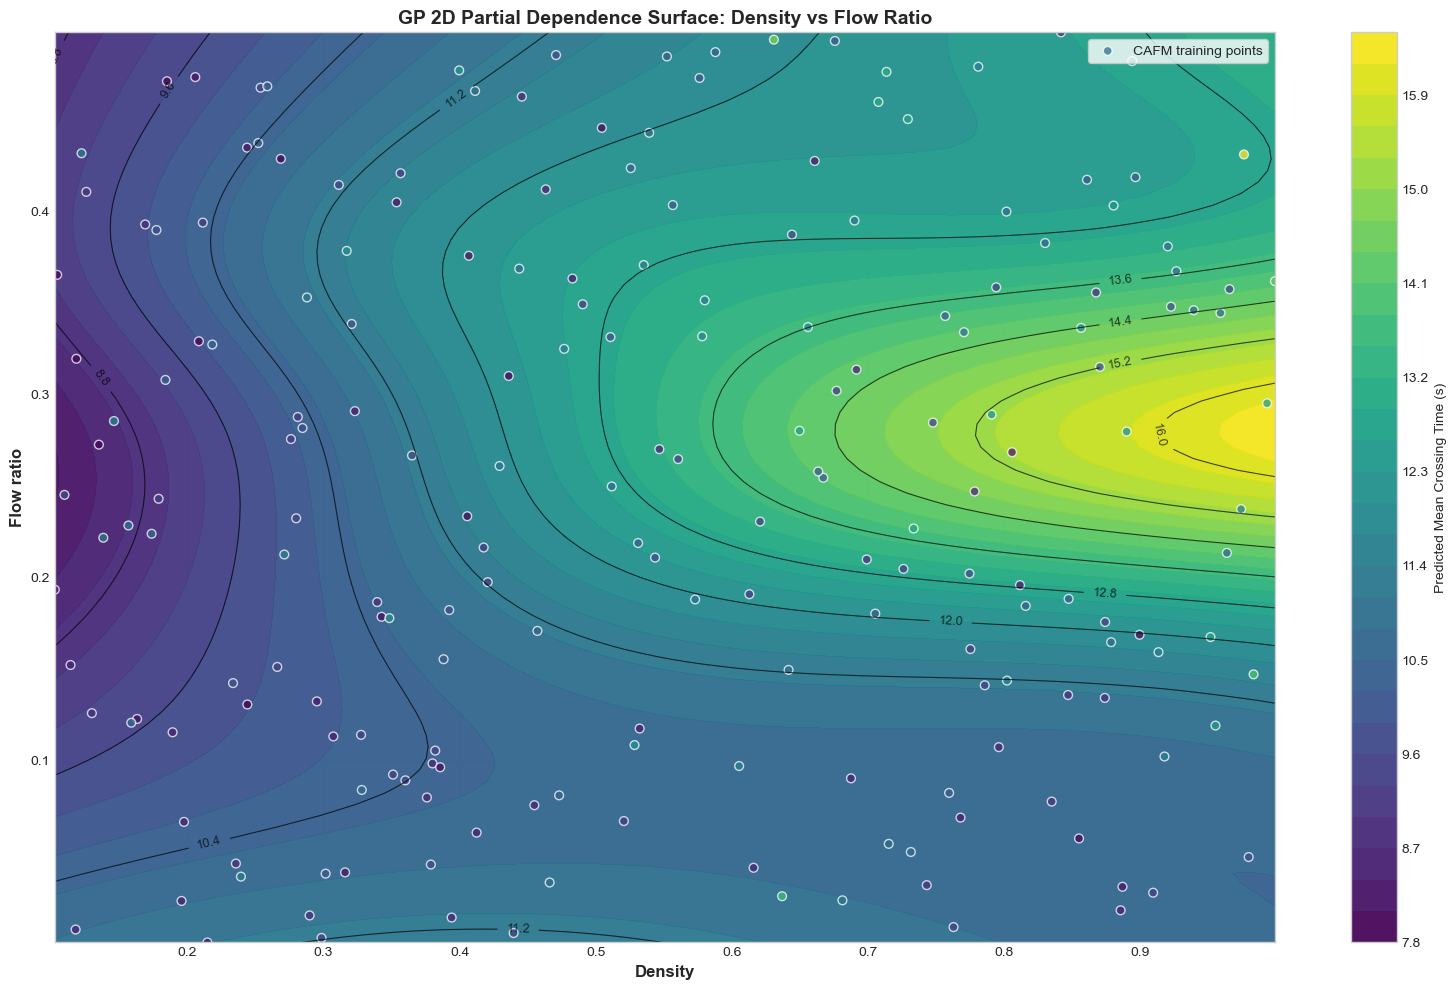

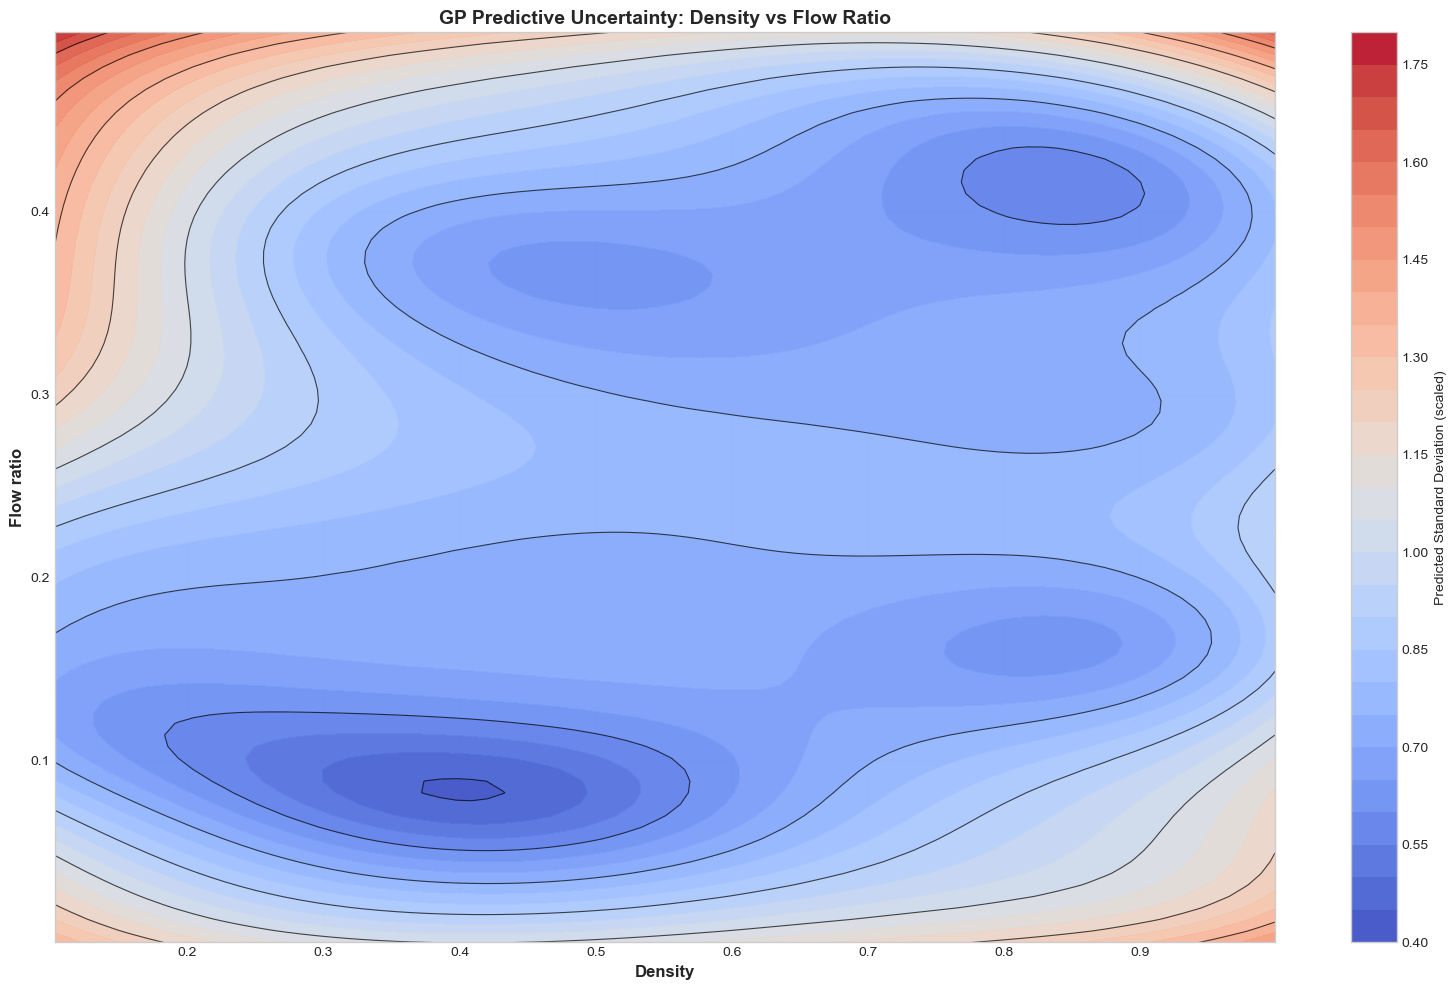

In [2]:
# Build a 2D GP surface for density and flow_ratio while fixing the remaining inputs at their mean.
path = r'D:\KIT\Datasets\cafm_lhs_300.npz'
data = np.load(path)
X = data['X'][:200]
Y = data['Y'][:200]
y = Y[:, 0]

param_names = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]
density_idx = param_names.index('density')
flow_idx = param_names.index('flow_ratio')

mean_point = X.mean(axis=0)

n_grid = 80
density_grid = np.linspace(X[:, density_idx].min(), X[:, density_idx].max(), n_grid)
flow_grid = np.linspace(X[:, flow_idx].min(), X[:, flow_idx].max(), n_grid)
D, F = np.meshgrid(density_grid, flow_grid)
X_grid = np.tile(mean_point, (n_grid * n_grid, 1))
X_grid[:, density_idx] = D.ravel()
X_grid[:, flow_idx] = F.ravel()

scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)

gp = GaussianProcessRegressor(
    kernel=1.0 * Matern(length_scale=np.ones(X.shape[1]), nu=2.5),
    alpha=1e-6,
    n_restarts_optimizer=5,
    random_state=42
)

gp.fit(X_scaled, y)

X_grid_s = scaler_x.transform(X_grid)
mean_grid, std_grid = gp.predict(X_grid_s, return_std=True)
mean_grid = mean_grid.reshape(n_grid, n_grid)
std_grid = std_grid.reshape(n_grid, n_grid)

plt.figure(figsize=(16, 10))
cont = plt.contourf(
    D,
    F,
    mean_grid,
    levels=30,
    cmap='viridis',
    alpha=0.95
)
plt.colorbar(cont, label='Predicted Mean Crossing Time (s)')
cs = plt.contour(D, F, mean_grid, levels=10, colors='k', linewidths=0.8, alpha=0.7)
plt.clabel(cs, inline=True, fontsize=9)
plt.scatter(
    X[:, density_idx],
    X[:, flow_idx],
    c=y,
    cmap='viridis',
    edgecolors='white',
    s=40,
    alpha=0.75,
    label='CAFM training points'
)
plt.xlabel('Density', fontsize=12, fontweight='bold')
plt.ylabel('Flow ratio', fontsize=12, fontweight='bold')
plt.title('GP 2D Partial Dependence Surface: Density vs Flow Ratio', fontsize=14, fontweight='bold')
plt.legend(frameon=True, loc='upper right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 10))
cont = plt.contourf(
    D,
    F,
    std_grid,
    levels=30,
    cmap='coolwarm',
    alpha=0.95
)
plt.colorbar(cont, label='Predicted Standard Deviation (scaled)')
plt.contour(D, F, std_grid, levels=10, colors='k', linewidths=0.8, alpha=0.7)
plt.xlabel('Density', fontsize=12, fontweight='bold')
plt.ylabel('Flow ratio', fontsize=12, fontweight='bold')
plt.title('GP Predictive Uncertainty: Density vs Flow Ratio', fontsize=14, fontweight='bold')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()